In [ ]:
# Cell 1: Imports & paths
import os
import re
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import pearsonr

# Single file to test; later you can batch (see last cell)
epoch_file = 'epochs_as_edf/epoch_001.edf'

# Optional: if your accel channels have different names, change here
ACCEL_NAMES = ['Ax', 'Ay', 'Az']  # try ['ACC_X','ACC_Y','ACC_Z'] etc. if needed


In [ ]:
# Cell 2 (REPLACE): Helper functions (rename channels, attach montage, objective metrics)
import re
import mne
import numpy as np

def attach_standard_montage(inst: mne.io.BaseRaw) -> mne.io.BaseRaw:
    """
    Normalize names like 'EEG P3-Pz' -> 'P3', then attach the 10-20 montage.
    Unmatched channels are set to 'misc' so montage application won't fail.
    """
    # --- 1) Rename channels to standard names
    mapping = {}
    for ch in inst.ch_names:
        new = ch
        new = re.sub(r'^EEG\s+', '', new)   # drop "EEG "
        new = re.sub(r'-Pz$', '', new)      # drop trailing "-Pz"
        # Legacy label mapping
        new = {'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}.get(new, new)
        mapping[ch] = new
    inst.rename_channels(mapping)

    # --- 2) Mark EEG channels (those that exist in the montage); others -> misc
    montage = mne.channels.make_standard_montage('standard_1020')
    montage_names = set(montage.ch_names)

    eeg_names = [ch for ch in inst.ch_names if ch in montage_names]
    if eeg_names:
        inst.set_channel_types({ch: 'eeg' for ch in eeg_names})

    other_names = [ch for ch in inst.ch_names if ch not in montage_names]
    # Keep known non-EEG types if they already are tagged; otherwise mark as misc
    to_misc = {}
    for ch in other_names:
        # Try to read current type; if unknown/unsupported, coerce to 'misc'
        try:
            idx = inst.ch_names.index(ch)
            # channel_type() with a single index returns a string
            ctype = mne.io.pick.channel_type(inst.info, idx)
        except Exception:
            ctype = 'misc'
        if ctype not in ('eeg', 'eog', 'ecg', 'emg', 'stim', 'resp', 'misc', 'ecog', 'seeg', 'dbs'):
            to_misc[ch] = 'misc'
    if to_misc:
        inst.set_channel_types(to_misc)

    # --- 3) Attach montage (positions for EEG channels only)
    inst.set_montage(montage, on_missing='ignore')

    # Report what happened
    unmatched = sorted(set(other_names) - set(to_misc.keys()))
    print(f"EEG (with positions): {len(eeg_names)} | Unmatched kept-as-is: {len(unmatched)} | Forced misc: {len(to_misc)}")
    if unmatched:
        print("  Unmatched kept-as-is:", unmatched[:10], "..." if len(unmatched) > 10 else "")
    if to_misc:
        print("  Forced to misc:", list(to_misc.keys())[:10], "..." if len(to_misc) > 10 else "")

    return inst


def robust_rms(inst):
    x = inst.get_data(picks='eeg')
    med = np.median(x, axis=1, keepdims=True)
    return float(np.sqrt(np.median((x - med) ** 2)))

# Cell 2 — REPLACE your bandpower() with this

def _choose_n_fft(inst, min_pts=64, sec_cap=2.0):
    """Pick an n_fft that works for very short epochs."""
    n_times = inst.n_times
    sfreq = inst.info['sfreq']
    cap = int(sfreq * sec_cap)                   # cap segment length to ~2 s
    n_fft_max = max(min(n_times, cap), min_pts)  # never exceed data length
    # round down to power of two (Welch works fine with non-pow2, but this is fast/stable)
    pow2 = 2 ** int(np.floor(np.log2(n_fft_max)))
    return max(pow2, min_pts)

def bandpower(inst, fmin, fmax):
    """Average bandpower across EEG channels, robust to short epochs."""
    if 'eeg' not in inst.get_channel_types():
        return np.nan
    n_fft = _choose_n_fft(inst)
    psd = inst.compute_psd(method='welch', fmin=fmin, fmax=fmax,
                           picks='eeg', n_fft=n_fft, n_overlap=n_fft // 2)
    freqs = psd.freqs
    pxx = psd.get_data()                    # (n_eeg, n_freqs)
    df = np.diff(freqs).mean() if len(freqs) > 1 else 0.0
    val = (pxx.sum(axis=1) * df).mean() if df > 0 else float('nan')
    return float(val)


# Cell 2 — REPLACE JUST THIS FUNCTION

def get_accel_from_inst(inst, accel_names=('Ax', 'Ay', 'Az')):
    """
    Return a (3, n_samples) numpy array with Ax, Ay, Az if present;
    otherwise try to infer accel channels from names; otherwise fall back
    to the 3 highest-variance 'misc' channels. Return None if nothing sensible.
    """
    # 1) If the expected names exist, use exactly those (filter to present only)
    present = [n for n in accel_names if n in inst.ch_names]
    if len(present) == 3:
        return inst.copy().pick(present).get_data()

    # 2) Try to find accel by common substrings (case-insensitive)
    low_map = {ch.lower(): ch for ch in inst.ch_names}
    candidates = []
    for key in ('ax', 'ay', 'az', 'accx', 'accy', 'accz', 'acc_x', 'acc_y', 'acc_z'):
        for low, orig in low_map.items():
            if key in low:
                candidates.append(orig)
    # de-dup while preserving order
    seen = set(); candidates = [c for c in candidates if not (c in seen or seen.add(c))]
    if len(candidates) >= 3:
        # try to order X,Y,Z if possible
        def xyz_key(name):
            s = name.lower()
            if 'x' in s: return 0
            if 'y' in s: return 1
            if 'z' in s: return 2
            return 99
        ordered = sorted(candidates, key=xyz_key)[:3]
        return inst.copy().pick(ordered).get_data()

    # 3) Fall back: take the 3 highest-variance MISC channels
    misc_picks = mne.pick_types(inst.info, misc=True, eeg=False, eog=False, stim=False)
    if len(misc_picks) >= 3:
        data = inst.get_data(picks=misc_picks)  # shape (n_misc, n_samples)
        top3 = np.argsort(data.std(axis=1))[-3:]
        return data[top3, :]

    # 4) Give up
    return None



In [ ]:
# Cell 3 (REPLACE): Load epoch & standardize channel names
epoch_file = 'epochs_as_edf/epoch_001.edf'  # adjust if needed

raw_epoch = mne.io.read_raw_edf(epoch_file, preload=True)
print(f"Loaded: {epoch_file}")
print("Original channel names (first 10):", raw_epoch.ch_names[:10])

raw_epoch = attach_standard_montage(raw_epoch)
print("After normalization (first 10):    ", raw_epoch.ch_names[:10])

# Show only EEG sensors in the plot (avoids misc/eog/etc.)
eeg_only = raw_epoch.copy().pick('eeg')
print(f"EEG channels available for montage: {len(eeg_only.ch_names)}")
_ = eeg_only.plot_sensors(show_names=False, kind='topomap')

# Cell 3b (REPLACE): Force correct channel types & montage (API-safe)

import mne

montage = mne.channels.make_standard_montage('standard_1020')
mont_names = set(montage.ch_names)

# Known non-EEG channels in your file
force_misc = ['CM', 'Ax', 'Ay', 'Az', 'X1:S3', 'X2:S2', 'X3:S1']
force_stim = ['Event']

to_types = {}

# a) EEG only if present in the montage
for ch in raw_epoch.ch_names:
    if ch in mont_names:
        to_types[ch] = 'eeg'

# b) Explicit non-EEG
for ch in force_misc:
    if ch in raw_epoch.ch_names:
        to_types[ch] = 'misc'
for ch in force_stim:
    if ch in raw_epoch.ch_names:
        to_types[ch] = 'stim'

# c) Any remaining channels that are still 'eeg' but not in montage -> misc
for ch in raw_epoch.ch_names:
    if ch not in to_types:
        ctype = raw_epoch.get_channel_types(picks=[ch])[0]  # <-- API-safe
        if ctype == 'eeg' and ch not in mont_names:
            to_types[ch] = 'misc'

if to_types:
    raw_epoch.set_channel_types(to_types)
raw_epoch.set_montage(montage, on_missing='ignore')

# Report
eeg_now  = [ch for ch, t in to_types.items() if t == 'eeg']
misc_now = [ch for ch, t in to_types.items() if t == 'misc']
stim_now = [ch for ch, t in to_types.items() if t == 'stim']
print(f"EEG with positions: {len(eeg_now)} -> {sorted(eeg_now)}")
print(f"Forced misc: {sorted(misc_now)}")
print(f"Stim channels: {sorted(stim_now)}")


In [ ]:
# Cell 4: Prepare data for ICA (EEG only, average reference, 1–40 Hz)
raw_eeg = raw_epoch.copy().pick('eeg')  # modern API
# Optional: drop obviously bad channels here via raw_eeg.drop_channels([...])

# Average reference is standard before ICA
raw_eeg.set_eeg_reference('average', projection=False)

# High-pass >= 1 Hz recommended for ICA; low-pass ~40 Hz is common
raw_eeg_for_ica = raw_eeg.copy().filter(l_freq=1.0, h_freq=40.0, fir_design='firwin',
                                        phase='zero-double', verbose='ERROR')

print(f"EEG channels: {len(raw_eeg_for_ica.ch_names)} | sfreq={raw_eeg_for_ica.info['sfreq']}")


In [ ]:
# Cell 5: Fit ICA
from mne.preprocessing import ICA

# Use up to 99% variance, but cap to avoid ill-conditioned fits on few channels
n_components = 0.99  # or set an int like min(20, len(raw_eeg.ch_names)-1)

ica = ICA(n_components=n_components, method='infomax', random_state=42, max_iter='auto')
print("Fitting ICA…")
ica.fit(raw_eeg_for_ica, reject_by_annotation=True, verbose='WARNING')

# Inspect sources/topos quickly (optional)
ica.plot_sources(raw_eeg_for_ica, show=False)
ica.plot_components(inst=raw_eeg_for_ica, show=False);


In [ ]:
# Cell 6 — Identify artifact ICs (accel correlation + optional ICLabel)
artifact_ics = []

# (A) Accelerometer correlation
accel = get_accel_from_inst(raw_epoch, accel_names=ACCEL_NAMES)
if accel is not None:
    ic_ts = ica.get_sources(raw_eeg).get_data()  # (n_ic, n_samples)
    L = min(ic_ts.shape[1], accel.shape[1])
    ic_ts = ic_ts[:, :L]
    accel = accel[:, :L]

    # magnitude & high-pass to emphasize motion
    from scipy import signal
    from scipy.stats import pearsonr
    accel_mag = np.sqrt((accel ** 2).sum(axis=0))
    b, a = signal.butter(4, 1.0, btype='high', fs=raw_eeg.info['sfreq'])
    accel_mag = signal.filtfilt(b, a, accel_mag)

    cors = np.array([abs(pearsonr(ic_ts[k], accel_mag)[0]) for k in range(ic_ts.shape[0])])
    thr = 0.30
    accel_bad = np.where(cors > thr)[0].tolist()
    artifact_ics.extend(accel_bad)

    plt.figure(figsize=(8, 3))
    plt.bar(np.arange(len(cors)), cors)
    plt.axhline(thr, linestyle='--', color='r')
    plt.title("IC ↔ accel magnitude |corr|"); plt.xlabel("IC index"); plt.ylabel("abs(corr)"); plt.show()
    print("Accel-correlated ICs:", accel_bad)
else:
    print("No accelerometer found (skipping accel correlation).")

# (B) Optional ICLabel
try:
    from mne_icalabel import label_components
    labels = label_components(raw_eeg_for_ica, ica, method='iclabel')
    probs = labels['y_pred_proba']  # (n_ic, 7)
    muscle_ics = np.where(probs[:, 1] > 0.70)[0].tolist()  # muscle
    other_ics  = np.where(probs[:, 6] > 0.70)[0].tolist()  # other
    artifact_ics.extend(muscle_ics + other_ics)
    print("ICLabel muscle:", muscle_ics, "| other:", other_ics)
except Exception as e:
    print("ICLabel unavailable or failed:", e)

artifact_ics = sorted(set(artifact_ics))
print(f"Identified {len(artifact_ics)} artifact ICs: {artifact_ics}")


In [ ]:
# Cell 7 — REPLACE with this robust version

# Apply ICA
raw_clean = raw_eeg.copy()
ica.exclude = artifact_ics
raw_clean = ica.apply(raw_clean.copy())

# Metrics (safe)
try:
    nfft_orig = _choose_n_fft(raw_eeg)
    nfft_clean = _choose_n_fft(raw_clean)
    print(f"n_fft used (orig/clean): {nfft_orig}/{nfft_clean}")
except Exception:
    pass

def safe(val_fn, *a, **k):
    try:
        return val_fn(*a, **k)
    except Exception as e:
        print(f"[metric skipped] {val_fn.__name__}: {e}")
        return float('nan')

rms_orig  = safe(robust_rms, raw_eeg)
rms_clean = safe(robust_rms, raw_clean)

low_orig  = safe(bandpower, raw_eeg, 0.0, 0.5)    # drift
low_clean = safe(bandpower, raw_clean, 0.0, 0.5)

line_orig  = safe(bandpower, raw_eeg, 55, 65)     # line band (adjust for your mains)
line_clean = safe(bandpower, raw_clean, 55, 65)

print(f"robust RMS (orig → clean): {rms_orig:.6g} → {rms_clean:.6g}")
print(f"low-drift power 0–0.5 Hz:  {low_orig:.6g} → {low_clean:.6g}")
print(f"line-noise 55–65 Hz:       {line_orig:.6g} → {line_clean:.6g}")


In [ ]:
# Cell 8: Visual comparison


def compare_channels(inst_a, inst_b, chans=('P3', 'C3', 'F3')):
    picks = [ch for ch in chans if ch in inst_a.ch_names and ch in inst_b.ch_names]
    if not picks:
        picks = inst_a.ch_names[:3]
    fig, axes = plt.subplots(len(picks), 2, figsize=(10, 3*len(picks)), sharex=True)
    if len(picks) == 1:
        axes = np.array([axes])
    fig.suptitle("Original EEG (left) vs Cleaned EEG (right)", fontsize=14)
    for r, ch in enumerate(picks):
        a = inst_a.copy().pick([ch]).get_data().ravel()
        b = inst_b.copy().pick([ch]).get_data().ravel()
        t = np.arange(a.size) / inst_a.info['sfreq']
        axes[r, 0].plot(t, a); axes[r, 0].set_ylabel(ch); axes[r, 0].set_xlim(t[0], t[-1])
        axes[r, 1].plot(t, b); axes[r, 1].set_xlim(t[0], t[-1])
    axes[-1, 0].set_xlabel("Time (s)"); axes[-1, 1].set_xlabel("Time (s)")
    plt.tight_layout(); plt.show()

compare_channels(raw_eeg, raw_clean, chans=('P3','C3','F3'))


In [ ]:
# Cell I2 — CLEAN ONE EPOCH (uses your previously-defined helpers)
import mne, numpy as np
from scipy import signal
from scipy.stats import pearsonr

# guard: make sure your helpers exist in this notebook
for fn in ("attach_standard_montage", "get_accel_from_inst", "robust_rms", "bandpower"):
    assert fn in globals(), f"Run the helper cell that defines `{fn}` before this."

CLEAN_SUFFIX = "_cleaned.edf"

def _accel_correlated_ics(ica, raw_eeg, raw_epoch, thresh=0.30):
    """Return IC indices correlated with accelerometer magnitude."""
    accel = get_accel_from_inst(raw_epoch)
    if accel is None:
        return []
    ic_ts = ica.get_sources(raw_eeg).get_data()  # (n_ic, n_times)
    L = min(ic_ts.shape[1], accel.shape[1])
    if L < 10:
        return []
    ic_ts = ic_ts[:, :L]
    accel = accel[:, :L]
    accel_mag = np.sqrt((accel ** 2).sum(axis=0))
    b, a = signal.butter(4, 1.0, btype='high', fs=raw_eeg.info['sfreq'])
    accel_mag = signal.filtfilt(b, a, accel_mag)
    cors = np.array([abs(pearsonr(ic_ts[k], accel_mag)[0]) for k in range(ic_ts.shape[0])])
    return np.where(cors > thresh)[0].tolist()

def clean_one_epoch_file(epoch_path: Path):
    # 1) load epoch
    raw_epoch = mne.io.read_raw_edf(str(epoch_path), preload=True, verbose="ERROR")

    # 2) standardize names + attach montage
    raw_epoch = attach_standard_montage(raw_epoch)

    # 3) EEG-only, average reference, 1–40 Hz for ICA fit
    raw_eeg = raw_epoch.copy().pick('eeg')
    if len(raw_eeg.ch_names) < 2:
        print(f"[skip] not enough EEG in {epoch_path.name}")
        return None

    raw_eeg.set_eeg_reference('average', projection=False)
    raw_eeg_f = raw_eeg.copy().filter(1.0, 40.0, fir_design='firwin',
                                      phase='zero-double', verbose='ERROR')

    # 4) fit ICA
    from mne.preprocessing import ICA
    ica = ICA(n_components=0.99, method='infomax', random_state=42, max_iter='auto')
    ica.fit(raw_eeg_f, reject_by_annotation=True, verbose='ERROR')

    # 5) choose artifact ICs: accel correlation + (optional) ICLabel
    artifact_ics = _accel_correlated_ics(ica, raw_eeg, raw_epoch, thresh=0.30)

    try:
        from mne_icalabel import label_components
        labels = label_components(raw_eeg_f, ica, method='iclabel')
        probs = labels['y_pred_proba']  # (n_ic, 7)
        artifact_ics += np.where(probs[:, 1] > 0.70)[0].tolist()  # muscle
        artifact_ics += np.where(probs[:, 6] > 0.70)[0].tolist()  # other
    except Exception:
        pass

    artifact_ics = sorted(set(artifact_ics))
    ica.exclude = artifact_ics

    # 6) apply to EEG and put back into full epoch
    raw_clean_eeg = ica.apply(raw_eeg.copy())
    combo = raw_epoch.copy()
    eeg_picks = mne.pick_types(combo.info, eeg=True)
    combo._data[eeg_picks, :] = raw_clean_eeg.get_data()

    # 7) save cleaned next to original (…/cleaned/epoch_###_cleaned.edf)
    out_dir = epoch_path.parent / "cleaned"
    out_dir.mkdir(exist_ok=True)
    out_file = out_dir / (epoch_path.stem + CLEAN_SUFFIX)
    mne.export.export_raw(str(out_file), combo, overwrite=True)

    # 8) QC metrics
    qc = {
        "epoch_file": str(epoch_path.relative_to(BASE_DIR)),
        "clean_file": str(out_file.relative_to(BASE_DIR)),
        "n_ic_removed": len(artifact_ics),
        "rms_orig":  float(robust_rms(raw_eeg)),
        "rms_clean": float(robust_rms(raw_clean_eeg)),
        "drift_orig": float(bandpower(raw_eeg, 0.0, 0.5)),
        "drift_clean": float(bandpower(raw_clean_eeg, 0.0, 0.5)),
        "line_orig":  float(bandpower(raw_eeg, 55, 65)),
        "line_clean": float(bandpower(raw_clean_eeg, 55, 65)),
    }
    return qc


In [ ]:
cleaned = list(EPOCHS_ROOT.rglob("*_epoch_*_cleaned.edf"))
print(f"Found {len(cleaned)} cleaned epochs.")
for p in cleaned[:5]:
    print(" •", p.relative_to(BASE_DIR))


In [ ]:
# Show a few raw epoch files
from pathlib import Path
BASE_DIR = Path(r"C:\Users\YOURNAME\OneDrive - Clemson University\Desktop\Data")
EPOCHS_ROOT = BASE_DIR / "epochs_as_edf_all"
print("Epoch root:", EPOCHS_ROOT)
print(*list(EPOCHS_ROOT.rglob("*_epoch_*.edf"))[:5], sep="\n")

# Show a few cleaned epoch files
print("\nCleaned examples:")
print(*[p for p in EPOCHS_ROOT.rglob("*_epoch_*_cleaned.edf")][:5], sep="\n")


In [ ]:
# Cell 10 (REPLACE): Batch over all epochs in epochs_as_edf_all, save into per-folder "cleaned/"

from pathlib import Path
import os, numpy as np, mne
from mne.preprocessing import ICA
from scipy import signal
from scipy.stats import pearsonr

# Point to your epochs root (adjust if needed)
username = os.getlogin()
EPOCHS_ROOT = Path(rf"C:\Users\{username}\OneDrive - Clemson University\Desktop\Data\epochs_as_edf_all")

def clean_one_epoch(epoch_path: Path):
    raw = mne.io.read_raw_edf(str(epoch_path), preload=True)
    raw = attach_standard_montage(raw)

    eeg = raw.copy().pick('eeg').set_eeg_reference('average', projection=False)
    eeg_f = eeg.copy().filter(1.0, 40.0, fir_design='firwin', phase='zero-double', verbose='ERROR')

    ica = ICA(n_components=0.99, method='infomax', random_state=42, max_iter='auto')
    ica.fit(eeg_f, reject_by_annotation=True, verbose='WARNING')

    # Try accel correlation (no ICLabel in batch for speed)
    accel = get_accel_from_inst(raw)
    bad = []
    if accel is not None:
        ic_ts = ica.get_sources(eeg).get_data()
        L = min(ic_ts.shape[1], accel.shape[1])
        if L > 10:
            ic_ts, accel = ic_ts[:, :L], accel[:, :L]
            accel_mag = np.sqrt((accel ** 2).sum(axis=0))
            b, a = signal.butter(4, 1.0, btype='high', fs=eeg.info['sfreq'])
            accel_mag = signal.filtfilt(b, a, accel_mag)
            cors = np.array([abs(pearsonr(ic_ts[k], accel_mag)[0]) for k in range(ic_ts.shape[0])])
            bad = np.where(cors > 0.30)[0].tolist()

    ica.exclude = sorted(set(bad))
    cleaned = ica.apply(eeg.copy())

    # Put cleaned EEG back into full Raw
    combo = raw.copy()
    eeg_picks = mne.pick_types(combo.info, eeg=True)
    combo._data[eeg_picks, :] = cleaned.get_data()

    # Save to per-epoch "cleaned" subfolder
    out_dir = epoch_path.parent / "cleaned"
    out_dir.mkdir(exist_ok=True)
    out_path = out_dir / (epoch_path.stem + "_cleaned.edf")
    mne.export.export_raw(str(out_path), combo, overwrite=True)
    return out_path

# Gather all epoch files recursively (both naming styles), skip already-cleaned
epoch_files = set(EPOCHS_ROOT.rglob("epoch_*.edf")) | set(EPOCHS_ROOT.rglob("*_epoch_*.edf"))
epoch_files = sorted(p for p in epoch_files if not p.name.endswith("_cleaned.edf"))

print(f"Found {len(epoch_files)} epoch files under {EPOCHS_ROOT}")
for p in epoch_files[:10]:
    print(" •", p.relative_to(EPOCHS_ROOT))

for p in epoch_files:
    print("→", p.relative_to(EPOCHS_ROOT))
    try:
        outp = clean_one_epoch(p)
        print("   Saved:", outp.relative_to(EPOCHS_ROOT))
    except Exception as e:
        print("   ERROR:", e)



Processing: James_OnField_040425_raw_epoch_001_cleaned.edf

Diagnosing: James_OnField_040425_raw_epoch_001_cleaned.edf
Extracting EDF parameters from C:\Users\2003d\OneDrive - Clemson University\Desktop\Data\epochs_as_edf_all\Men_OnField_James_OnField_040425_raw\cleaned\James_OnField_040425_raw_epoch_001_cleaned.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1499  =      0.000 ...     4.997 secs...

1. Total channels: 30
   Channel names: ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'CM', 'A1']...

2. Channel types: {'eeg': 29, 'stim': 1}

3. EEG channels found: 29
   EEG channel names: ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'CM', 'A1']...

4. Montage attached: False

5. Attempting to attach standard 10-20 montage...
   Channels matching standard 10-20: 21
   Matching channels: ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'A1', 'Fp1']...
Processing 29 EEG channels


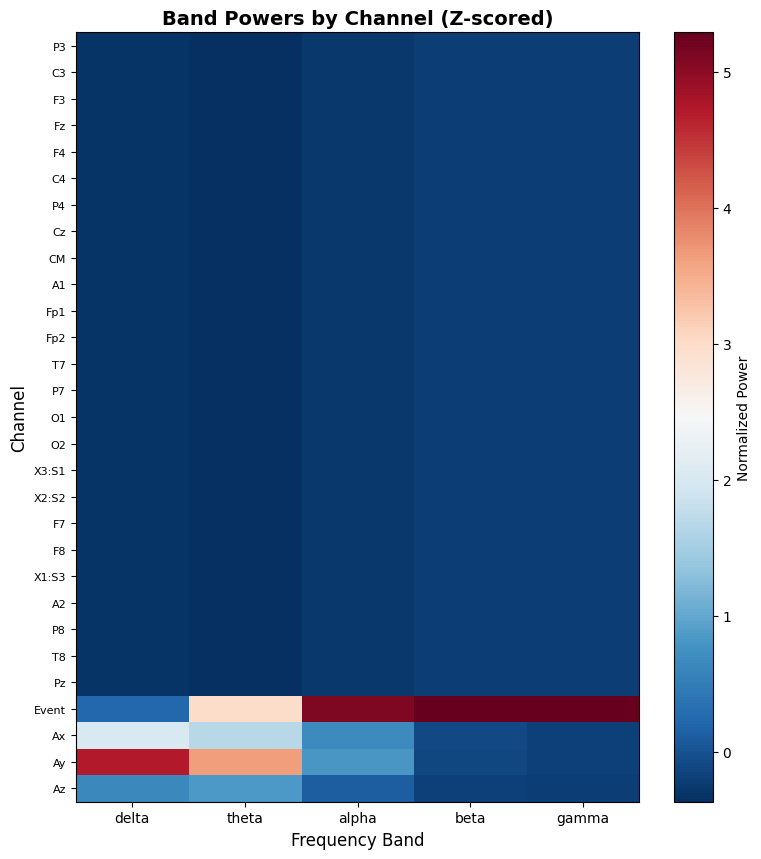


Cognitive Workload Indices:
  engagement_index: 0.2202
  frontal_theta: 0.0000
  parietal_alpha: 0.0000
  workload_index: 0.9138
  theta_alpha_ratio: 2.2643
  beta_alpha_ratio: 0.7189

Extracted 152 total features
Ready for machine learning!


In [133]:
# Diagnostic cell - Run this first to understand your data
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

def diagnose_eeg_file(file_path):
    """
    Diagnose issues with EEG file for topography plotting
    """
    print(f"\n{'='*60}")
    print(f"Diagnosing: {Path(file_path).name}")
    print('='*60)
    
    # Load file
    raw = mne.io.read_raw_edf(str(file_path), preload=True)
    
    # Check channels
    print(f"\n1. Total channels: {len(raw.ch_names)}")
    print(f"   Channel names: {raw.ch_names[:10]}...")
    
    # Check channel types
    ch_types = raw.get_channel_types()
    type_counts = {}
    for t in ch_types:
        type_counts[t] = type_counts.get(t, 0) + 1
    print(f"\n2. Channel types: {type_counts}")
    
    # Check for EEG channels
    eeg_picks = mne.pick_types(raw.info, eeg=True, exclude=[])
    print(f"\n3. EEG channels found: {len(eeg_picks)}")
    if len(eeg_picks) > 0:
        eeg_names = [raw.ch_names[i] for i in eeg_picks]
        print(f"   EEG channel names: {eeg_names[:10]}...")
    
    # Check montage
    montage = raw.get_montage()
    print(f"\n4. Montage attached: {montage is not None}")
    if montage:
        print(f"   Montage channels: {len(montage.ch_names)}")
    
    # Try to attach standard montage
    print("\n5. Attempting to attach standard 10-20 montage...")
    standard_montage = mne.channels.make_standard_montage('standard_1020')
    standard_names = set(standard_montage.ch_names)
    
    matching_channels = [ch for ch in raw.ch_names if ch in standard_names]
    print(f"   Channels matching standard 10-20: {len(matching_channels)}")
    if matching_channels:
        print(f"   Matching channels: {matching_channels[:10]}...")
    
    return raw

# Fixed topography extraction that works with your data
def extract_band_powers_simple(raw_clean, bands=None):
    """
    Simple band power extraction that doesn't require montage
    """
    if bands is None:
        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 45)
        }
    
    # Pick only EEG channels
    eeg_picks = mne.pick_types(raw_clean.info, eeg=True, exclude=[])
    
    if len(eeg_picks) == 0:
        print("No EEG channels found! Checking if any channels contain EEG data...")
        # Try to identify EEG channels by name patterns
        eeg_patterns = ['Fp', 'F', 'C', 'P', 'O', 'T']
        potential_eeg = []
        for idx, ch in enumerate(raw_clean.ch_names):
            if any(ch.startswith(pat) for pat in eeg_patterns):
                potential_eeg.append(idx)
        
        if potential_eeg:
            print(f"Found {len(potential_eeg)} potential EEG channels by name pattern")
            eeg_picks = potential_eeg
            # Set them as EEG type
            raw_clean.set_channel_types({raw_clean.ch_names[i]: 'eeg' for i in eeg_picks})
    
    if len(eeg_picks) == 0:
        print("ERROR: No EEG channels found in the data!")
        return None, None, None
    
    # Get EEG data
    raw_eeg = raw_clean.copy().pick([raw_clean.ch_names[i] for i in eeg_picks])
    
    print(f"Processing {len(raw_eeg.ch_names)} EEG channels")
    
    # Compute PSD
    spectrum = raw_eeg.compute_psd(method='welch', fmin=0.5, fmax=50,
                                   n_fft=min(256, raw_eeg.n_times//4),
                                   n_overlap=min(128, raw_eeg.n_times//8),
                                   verbose=False)
    psds = spectrum.get_data()
    freqs = spectrum.freqs
    
    # Extract band powers
    band_powers = {}
    for band_name, (fmin, fmax) in bands.items():
        freq_mask = (freqs >= fmin) & (freqs <= fmax)
        if np.any(freq_mask):
            band_power = psds[:, freq_mask].mean(axis=1)
            band_powers[band_name] = band_power
    
    return band_powers, raw_eeg.ch_names, raw_eeg

def plot_band_powers_as_matrix(band_powers, ch_names, save_path=None):
    """
    Plot band powers as a matrix when topographic plot isn't possible
    """
    if not band_powers:
        print("No band powers to plot!")
        return None
    
    # Create matrix of band powers
    bands = list(band_powers.keys())
    n_channels = len(ch_names)
    n_bands = len(bands)
    
    power_matrix = np.zeros((n_channels, n_bands))
    for j, band in enumerate(bands):
        power_matrix[:, j] = band_powers[band]
    
    # Normalize each band separately for better visualization
    for j in range(n_bands):
        if power_matrix[:, j].std() > 0:
            power_matrix[:, j] = (power_matrix[:, j] - power_matrix[:, j].mean()) / power_matrix[:, j].std()
    
    # Create plot
    fig, ax = plt.subplots(figsize=(8, max(6, n_channels * 0.3)))
    
    im = ax.imshow(power_matrix, cmap='RdBu_r', aspect='auto')
    
    # Set ticks
    ax.set_xticks(range(n_bands))
    ax.set_xticklabels(bands)
    ax.set_yticks(range(n_channels))
    ax.set_yticklabels(ch_names, fontsize=8)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Normalized Power')
    
    ax.set_xlabel('Frequency Band', fontsize=12)
    ax.set_ylabel('Channel', fontsize=12)
    ax.set_title('Band Powers by Channel (Z-scored)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig

def compute_workload_indices(band_powers, ch_names):
    """
    Compute cognitive workload indices from band powers
    """
    indices = {}
    
    # Helper to get power for specific channels
    def get_channel_power(band, channel_patterns):
        matching_indices = []
        for pattern in channel_patterns:
            for i, ch in enumerate(ch_names):
                if pattern in ch or ch.startswith(pattern):
                    matching_indices.append(i)
        if matching_indices and band in band_powers:
            return np.mean(band_powers[band][matching_indices])
        return None
    
    # 1. Engagement Index (Beta / (Alpha + Theta))
    if all(b in band_powers for b in ['beta', 'alpha', 'theta']):
        beta_mean = np.mean(band_powers['beta'])
        alpha_mean = np.mean(band_powers['alpha'])
        theta_mean = np.mean(band_powers['theta'])
        indices['engagement_index'] = beta_mean / (alpha_mean + theta_mean + 1e-10)
    
    # 2. Frontal Theta (mental effort)
    frontal_theta = get_channel_power('theta', ['Fz', 'F3', 'F4', 'Fp1', 'Fp2', 'F'])
    if frontal_theta is not None:
        indices['frontal_theta'] = frontal_theta
    
    # 3. Parietal Alpha (attention/relaxation)
    parietal_alpha = get_channel_power('alpha', ['Pz', 'P3', 'P4', 'P'])
    if parietal_alpha is not None:
        indices['parietal_alpha'] = parietal_alpha
    
    # 4. Workload Index (Frontal Theta / Parietal Alpha)
    if frontal_theta is not None and parietal_alpha is not None:
        indices['workload_index'] = frontal_theta / (parietal_alpha + 1e-10)
    
    # 5. Theta/Alpha Ratio (overall)
    if 'theta' in band_powers and 'alpha' in band_powers:
        indices['theta_alpha_ratio'] = np.mean(band_powers['theta']) / (np.mean(band_powers['alpha']) + 1e-10)
    
    # 6. Beta/Alpha Ratio (arousal)
    if 'beta' in band_powers and 'alpha' in band_powers:
        indices['beta_alpha_ratio'] = np.mean(band_powers['beta']) / (np.mean(band_powers['alpha']) + 1e-10)
    
    return indices

# Main processing function
def process_cleaned_epoch(file_path, save_plots=True):
    """
    Process a cleaned epoch and extract all features
    """
    print(f"\nProcessing: {Path(file_path).name}")
    
    # Load and diagnose
    raw = diagnose_eeg_file(file_path)
    
    # Extract band powers
    band_powers, ch_names, raw_eeg = extract_band_powers_simple(raw)
    
    if band_powers is None:
        print("Failed to extract band powers!")
        return None
    
    # Plot as matrix (since topomap might not work)
    if save_plots:
        plot_path = Path(file_path).parent / f"{Path(file_path).stem}_bandpowers.png"
        plot_band_powers_as_matrix(band_powers, ch_names, save_path=str(plot_path))
    
    # Compute workload indices
    indices = compute_workload_indices(band_powers, ch_names)
    
    print("\nCognitive Workload Indices:")
    for key, value in indices.items():
        if value is not None:
            print(f"  {key}: {value:.4f}")
    
    # Create feature vector for ML
    features = {}
    
    # Add band powers for each channel
    for band, powers in band_powers.items():
        for i, ch in enumerate(ch_names):
            features[f'{band}_{ch}'] = powers[i]
    
    # Add computed indices
    features.update(indices)
    
    # Add file identifier
    features['file_id'] = Path(file_path).stem
    
    return features

# Example usage
if __name__ == "__main__":
    import os
    from pathlib import Path
    
    username = os.getlogin()
    BASE_DIR = Path(rf"C:\Users\{username}\OneDrive - Clemson University\Desktop\Data")
    EPOCHS_ROOT = BASE_DIR / "epochs_as_edf_all"
    
    # Find cleaned files
    cleaned_files = list(EPOCHS_ROOT.rglob("*_cleaned.edf"))
    
    if cleaned_files:
        # Process first file as example
        features = process_cleaned_epoch(cleaned_files[0])
        
        if features:
            print(f"\nExtracted {len(features)} total features")
            print("Ready for machine learning!")
    else:
        print("No cleaned files found!")

Found 506 cleaned files

Creating topography for: James_OnField_040425_raw_epoch_001_cleaned.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Successfully mapped 21 channels for topography
Channels: ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'A1', 'Fp1', 'Fp2', 'T7', 'P7', 'O1', 'O2', 'F7', 'F8', 'A2', 'P8', 'T8', 'Pz']
Saved topography to C:\Users\2003d\OneDrive - Clemson University\Desktop\Data\epochs_as_edf_all\Men_OnField_James_OnField_040425_raw\cleaned\James_OnField_040425_raw_epoch_001_cleaned_brain_topo.png


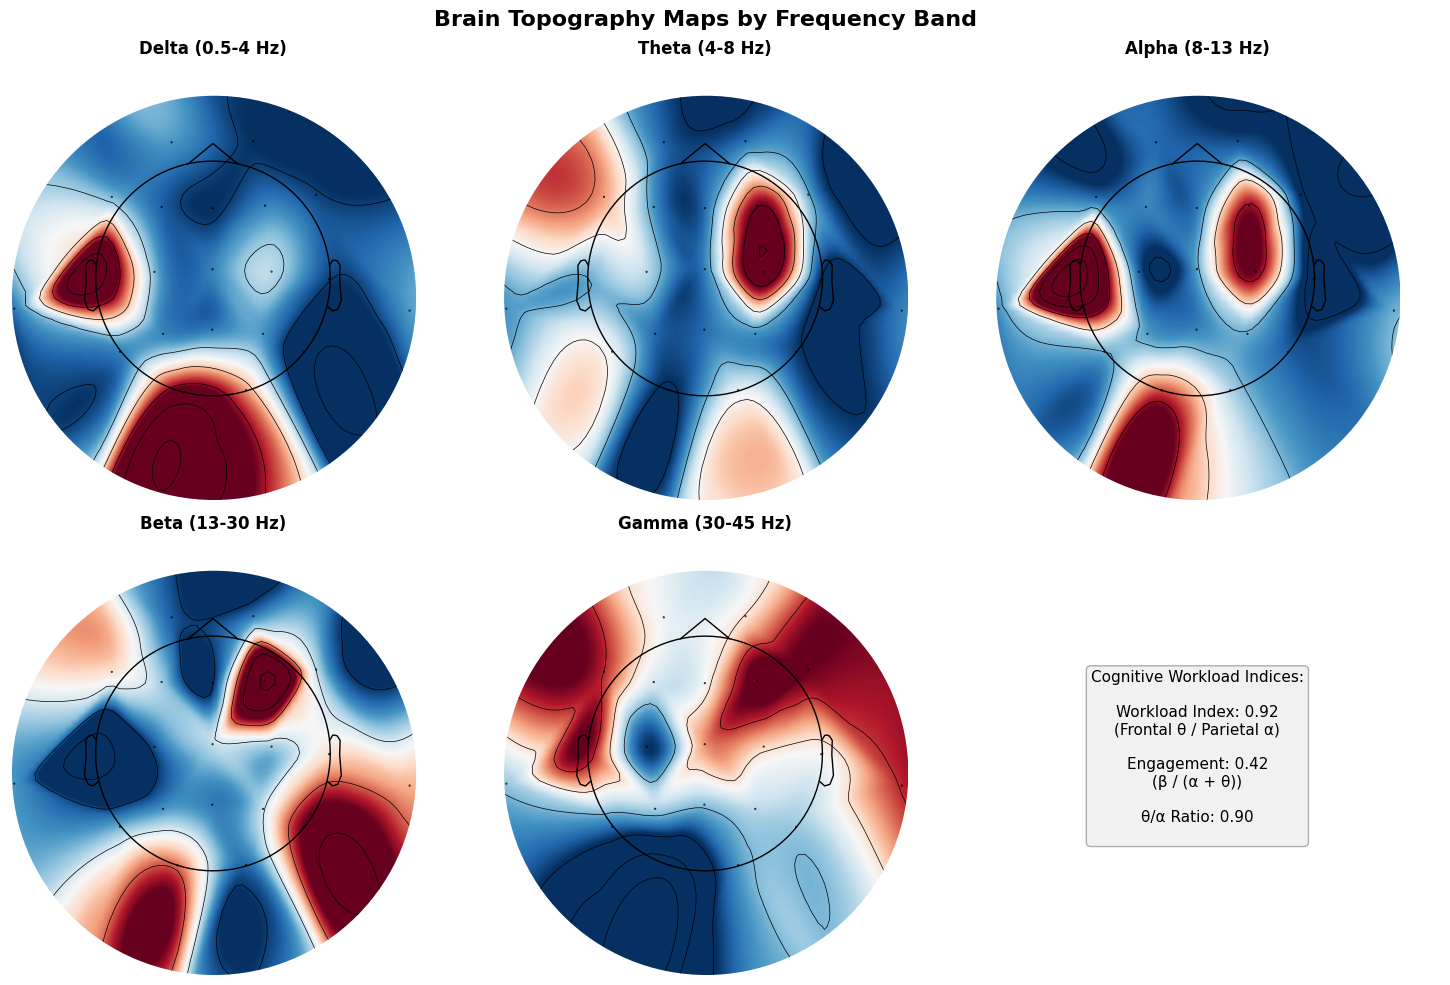


Creating comparison topography...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Successfully mapped 21 channels for topography
Channels: ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'A1', 'Fp1', 'Fp2', 'T7', 'P7', 'O1', 'O2', 'F7', 'F8', 'A2', 'P8', 'T8', 'Pz']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Successfully mapped 21 channels for topography
Channels: ['P3', 'C3', 'F3', 'Fz', 'F4', 'C4', 'P4', 'Cz', 'A1', 'Fp1', 'Fp2', 'T7', 'P7', 'O1', 'O2', 'F7', 'F8', 'A2', 'P8', 'T8', 'Pz']


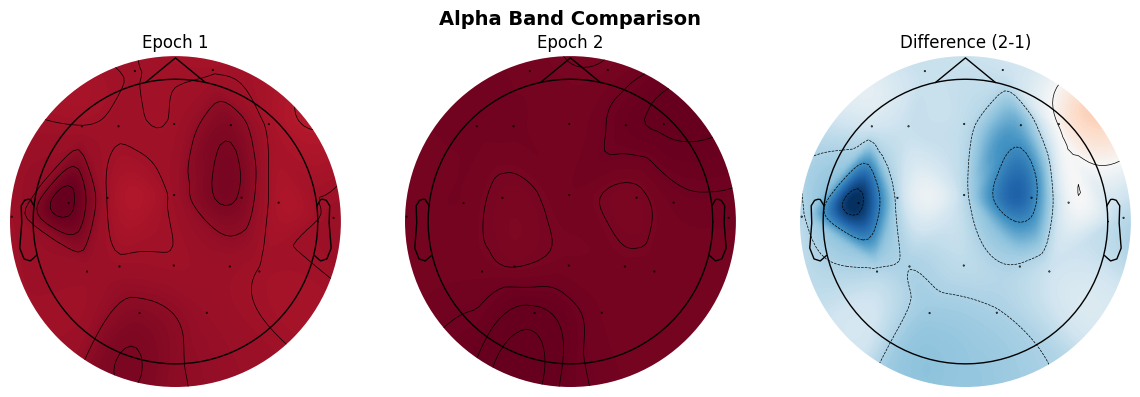

In [134]:
# Proper Brain Topography Generation
import mne
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

def fix_channel_montage(raw):
    """
    Fix channel names and attach proper montage for topography
    """
    # Get current channel names
    current_names = raw.ch_names.copy()
    
    # Create mapping to standard names
    channel_mapping = {}
    
    # Standard 10-20 channels that might need mapping
    standard_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 
                        'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8',
                        'Fz', 'Cz', 'Pz', 'Oz', 'Fpz', 'CPz', 'POz', 'FCz',
                        'A1', 'A2']
    
    # Keep EEG channels that match standard names
    for ch in current_names:
        if ch in standard_channels:
            channel_mapping[ch] = ch
        # Skip non-EEG channels
        elif ch in ['CM', 'Event', 'Ax', 'Ay', 'Az', 'X1:S3', 'X2:S2', 'X3:S1']:
            continue
        # Map any remaining EEG-like channels
        else:
            # Check if it's an EEG channel pattern we haven't handled
            for std in standard_channels:
                if ch.upper() == std.upper() and std not in channel_mapping.values():
                    channel_mapping[ch] = std
                    break
    
    # Pick only the channels we can map
    channels_to_keep = list(channel_mapping.keys())
    
    if not channels_to_keep:
        print("Error: No standard EEG channels found!")
        return None
    
    # Create a new raw object with only mapped channels
    raw_topo = raw.copy().pick_channels(channels_to_keep)
    
    # Rename to standard names if needed
    if channel_mapping:
        rename_dict = {k: v for k, v in channel_mapping.items() if k != v}
        if rename_dict:
            raw_topo.rename_channels(rename_dict)
    
    # Set all as EEG type
    raw_topo.set_channel_types({ch: 'eeg' for ch in raw_topo.ch_names})
    
    # Attach standard montage
    montage = mne.channels.make_standard_montage('standard_1020')
    raw_topo.set_montage(montage, on_missing='ignore')
    
    print(f"Successfully mapped {len(raw_topo.ch_names)} channels for topography")
    print(f"Channels: {raw_topo.ch_names}")
    
    return raw_topo

def compute_band_topography(raw_topo, band='alpha', fmin=8, fmax=13):
    """
    Compute topography for a specific frequency band
    """
    # Compute PSD
    spectrum = raw_topo.compute_psd(method='welch', fmin=fmin, fmax=fmax,
                                    n_fft=min(256, raw_topo.n_times//4),
                                    n_overlap=min(128, raw_topo.n_times//8),
                                    verbose=False)
    
    # Get power data
    psds = spectrum.get_data()
    freqs = spectrum.freqs
    
    # Average across frequency band
    band_power = psds.mean(axis=1)
    
    return band_power

def create_brain_topography(file_path, save_path=None):
    """
    Create proper brain topography plots
    """
    # Load data
    raw = mne.io.read_raw_edf(str(file_path), preload=True, verbose=False)
    
    # Fix montage
    raw_topo = fix_channel_montage(raw)
    
    if raw_topo is None:
        print("Failed to create topography - no suitable channels")
        return None
    
    # Define frequency bands
    bands = {
        'Delta (0.5-4 Hz)': (0.5, 4),
        'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-13 Hz)': (8, 13),
        'Beta (13-30 Hz)': (13, 30),
        'Gamma (30-45 Hz)': (30, 45)
    }
    
    # Create figure with subplots
    fig = plt.figure(figsize=(15, 10))
    
    # Main title
    fig.suptitle('Brain Topography Maps by Frequency Band', fontsize=16, fontweight='bold')
    
    # Create topomaps for each band
    for idx, (band_name, (fmin, fmax)) in enumerate(bands.items()):
        # Compute band power
        band_power = compute_band_topography(raw_topo, band_name.split()[0].lower(), fmin, fmax)
        
        # Create subplot
        ax = fig.add_subplot(2, 3, idx + 1)
        
        # Plot topomap
        im = mne.viz.plot_topomap(
            band_power,
            raw_topo.info,
            axes=ax,
            show=False,
            cmap='RdBu_r',
            vlim=(np.percentile(band_power, 5), np.percentile(band_power, 95)),
            contours=6,
            sensors=True,
            sphere='auto'
        )
        
        ax.set_title(band_name, fontsize=12, fontweight='bold')
    
    # Add a subplot for cognitive indices
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    
    # Calculate cognitive indices
    alpha_power = compute_band_topography(raw_topo, 'alpha', 8, 13)
    theta_power = compute_band_topography(raw_topo, 'theta', 4, 8)
    beta_power = compute_band_topography(raw_topo, 'beta', 13, 30)
    
    # Find frontal and parietal channels
    frontal_chs = [i for i, ch in enumerate(raw_topo.ch_names) if ch[0] == 'F']
    parietal_chs = [i for i, ch in enumerate(raw_topo.ch_names) if ch[0] == 'P']
    
    indices_text = "Cognitive Workload Indices:\n\n"
    
    if len(frontal_chs) > 0 and len(parietal_chs) > 0:
        frontal_theta = np.mean(theta_power[frontal_chs])
        parietal_alpha = np.mean(alpha_power[parietal_chs])
        workload_index = frontal_theta / (parietal_alpha + 1e-10)
        indices_text += f"Workload Index: {workload_index:.2f}\n"
        indices_text += f"(Frontal θ / Parietal α)\n\n"
    
    engagement = np.mean(beta_power) / (np.mean(alpha_power) + np.mean(theta_power) + 1e-10)
    indices_text += f"Engagement: {engagement:.2f}\n"
    indices_text += f"(β / (α + θ))\n\n"
    
    theta_alpha_ratio = np.mean(theta_power) / (np.mean(alpha_power) + 1e-10)
    indices_text += f"θ/α Ratio: {theta_alpha_ratio:.2f}\n"
    
    ax6.text(0.5, 0.5, indices_text, fontsize=11, ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved topography to {save_path}")
    
    plt.show()
    
    return fig, raw_topo

def create_comparison_topography(file1, file2, labels=['Epoch 1', 'Epoch 2'], band='alpha'):
    """
    Create side-by-side topography comparison
    """
    band_ranges = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 45)
    }
    
    fmin, fmax = band_ranges.get(band.lower(), (8, 13))
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    powers = []
    
    for idx, (file_path, label) in enumerate(zip([file1, file2], labels)):
        raw = mne.io.read_raw_edf(str(file_path), preload=True, verbose=False)
        raw_topo = fix_channel_montage(raw)
        
        if raw_topo:
            band_power = compute_band_topography(raw_topo, band, fmin, fmax)
            powers.append(band_power)
            
            # Plot individual topography
            mne.viz.plot_topomap(
                band_power,
                raw_topo.info,
                axes=axes[idx],
                show=False,
                cmap='RdBu_r',
                contours=4
            )
            axes[idx].set_title(label)
    
    # Plot difference
    if len(powers) == 2:
        diff = powers[1] - powers[0]
        mne.viz.plot_topomap(
            diff,
            raw_topo.info,
            axes=axes[2],
            show=False,
            cmap='RdBu_r',
            contours=4
        )
        axes[2].set_title('Difference (2-1)')
    
    plt.suptitle(f'{band.capitalize()} Band Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

def batch_create_topographies(cleaned_dir, output_dir=None):
    """
    Create topographies for all cleaned files
    """
    cleaned_path = Path(cleaned_dir)
    cleaned_files = list(cleaned_path.rglob("*_cleaned.edf"))
    
    if output_dir is None:
        output_dir = cleaned_path / "topographies"
    else:
        output_dir = Path(output_dir)
    
    output_dir.mkdir(exist_ok=True)
    
    print(f"Creating topographies for {len(cleaned_files)} files...")
    
    successful = 0
    failed = []
    
    for file_path in cleaned_files:
        try:
            output_file = output_dir / f"{file_path.stem}_topography.png"
            fig, raw_topo = create_brain_topography(file_path, save_path=str(output_file))
            if fig:
                successful += 1
                plt.close(fig)
        except Exception as e:
            print(f"Failed: {file_path.name} - {str(e)}")
            failed.append(file_path.name)
    
    print(f"\nCompleted: {successful}/{len(cleaned_files)} successful")
    if failed:
        print(f"Failed files: {failed[:5]}...")
    
    return successful, failed

# Example usage
if __name__ == "__main__":
    import os
    
    username = os.getlogin()
    BASE_DIR = Path(rf"C:\Users\{username}\OneDrive - Clemson University\Desktop\Data")
    EPOCHS_ROOT = BASE_DIR / "epochs_as_edf_all"
    
    # Find a cleaned file
    cleaned_files = list(EPOCHS_ROOT.rglob("*_cleaned.edf"))
    
    if cleaned_files:
        print(f"Found {len(cleaned_files)} cleaned files")
        
        # Create topography for first file
        test_file = cleaned_files[0]
        print(f"\nCreating topography for: {test_file.name}")
        
        fig, raw_topo = create_brain_topography(
            test_file,
            save_path=str(test_file.parent / f"{test_file.stem}_brain_topo.png")
        )
        
        # Optional: Compare two epochs
        if len(cleaned_files) >= 2:
            print("\nCreating comparison topography...")
            comp_fig = create_comparison_topography(
                cleaned_files[0], 
                cleaned_files[1],
                labels=['Epoch 1', 'Epoch 2'],
                band='alpha'
            )